# Wine Classification using K-Nearest Neighbors (KNN)

This notebook demonstrates a complete machine learning workflow to classify wine types using the Scikit-Learn Wine dataset. The process includes data preprocessing, pipeline construction, hyperparameter tuning via Grid Search, and model evaluation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV

## 1. Data Loading and Preprocessing

We load the wine dataset as a pandas DataFrame and split it into training and testing sets. We use stratified sampling to ensure the class distribution remains consistent across both sets.

In [4]:
df = load_wine(as_frame=True).frame
X = df.drop(['target'],axis=1)
y = df['target']

X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## 2. Model Pipeline Construction

To ensure a robust workflow and prevent data leakage, we utilize a `Pipeline`. This includes a `StandardScaler` to normalize features (critical for distance-based algorithms like KNN) followed by the `KNeighborsClassifier`.

In [5]:
knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('knn',KNeighborsClassifier())
    ]
)
knn_model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

## 3. Hyperparameter Tuning

We define a parameter grid to optimize the number of neighbors, the weight function, and the power parameter for the Minkowski metric. `GridSearchCV` is used with 5-fold cross-validation to find the most effective configuration.

In [6]:
grid = {
    "knn__n_neighbors" : [3,5,7,11,13,17],
    "knn__weights" :['uniform','distance'],
    "knn__p" : [1,2]
}


grid_search = GridSearchCV(
    estimator = knn_model,
    param_grid = grid,
    cv = 5
)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 11, 13, 17],
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']})

In [7]:
grid_search.best_params_

{'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'uniform'}

### Best Estimator

The following cell retrieves the optimal pipeline configuration identified during the grid search.

In [8]:
grid_search.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=7, p=1))])

## 4. Model Evaluation

We utilize the best estimator to make predictions on the unseen test set and evaluate the performance using accuracy metrics.

In [9]:
model = grid_search.best_estimator_

y_pred= model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



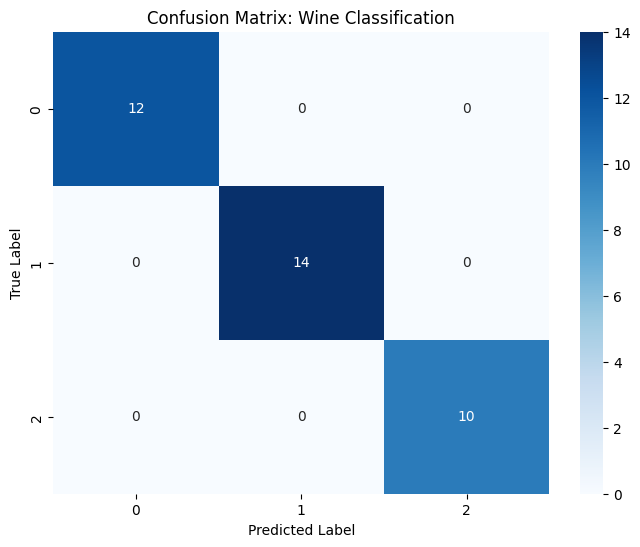

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Ensure model predictions are generated
model = grid_search.best_estimator_
y_pred = model.predict(X_test)

# Display detailed classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize the results with a Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Wine Classification')
plt.show()